**Goal:** train, evaluate, and stress-test your first machine-learning model -- using the
toolkit from the concept note and before the course has taught you any algorithm at all.
That is the point: feel the workflow first. Pairs with the concept note
[The ML Toolkit and Your First Model](l02_concept_ml_toolkit_first_model.qmd).

> **Previously:** L01 -- What Is Machine Learning?  |  **Next:** Unit II -- linear regression

> This page is the read-only view. To run the lab, open the notebook
> (`l02_lab_ml_toolkit_first_model.ipynb`) -- in Colab via the badge on the concept page,
> or locally.

## Scenario

A biodiversity team monitors two frog species by their nighttime calls: the common coqui
(*Eleutherodactylus coqui*) and the mountain coqui (*E. portoricensis*). Each recorded call
is reduced to two acoustic features: the pitch of its "co" note and the pitch of its "qui"
note, both in kHz. Your job: a program that labels the species.

The data below is **synthetic** (generated with a fixed seed, so everyone gets identical
numbers) with *fictionalized but plausible* values -- the framing is real, the kilohertz are
not field measurements.

## Setup

The setup is **two cells** (this is the pattern every lab in the course uses). Run them top
to bottom. The first only installs; the second imports, seeds the random number generator,
and builds the data -- so when you re-run imports while experimenting, you do not re-install.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy, pandas and matplotlib, so this is effectively a
# no-op there; it models the install step. Locally the uv equivalent is the comment below.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)          # fixed seed: identical data for everyone
n = 150                                  # calls per species

calls = pd.DataFrame({
    "co_khz":  np.concatenate([rng.normal(1.15, 0.18, n), rng.normal(1.45, 0.18, n)]),
    "qui_khz": np.concatenate([rng.normal(2.05, 0.25, n), rng.normal(2.45, 0.25, n)]),
    "species": ["coqui"] * n + ["portoricensis"] * n,
})
print(calls.shape)
calls.head(3)

(300, 3)


,co_khz,qui_khz,species
0,1.156155,2.088100,coqui
1,1.394755,1.763687,coqui
2,1.370450,2.149366,coqui


~~~text
(300, 3)
     co_khz   qui_khz species
0  1.156155  2.088100   coqui
1  1.394755  1.763687   coqui
2  1.370450  2.149366   coqui
~~~

## Step 1: Look Before You Model

Always plot first. Two features means one scatter plot shows everything:

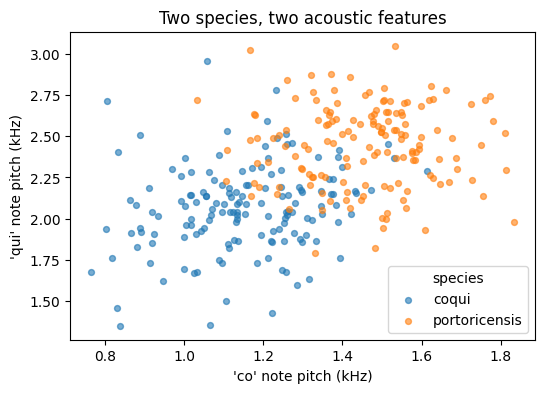

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, group in calls.groupby("species"):
    ax.scatter(group["co_khz"], group["qui_khz"], label=name, alpha=0.6, s=18)
ax.set_xlabel("'co' note pitch (kHz)")
ax.set_ylabel("'qui' note pitch (kHz)")
ax.legend(title="species")
ax.set_title("Two species, two acoustic features")
plt.show()

The clouds overlap. No vertical or horizontal line separates them cleanly -- some calls are
genuinely ambiguous. Keep that in mind: **no classifier will be perfect here**, and that is
normal.

### Naive approach: write the rule by hand

The mountain coqui tends to sing higher. So hand-code the obvious rule: if the "qui" note is
above 2.25 kHz, call it *portoricensis*.

In [4]:
hand_rule = np.where(calls["qui_khz"] > 2.25, "portoricensis", "coqui")
hand_acc = (hand_rule == calls["species"]).mean()
print(f"hand rule accuracy: {hand_acc:.3f}")

hand rule accuracy: 0.773


~~~text
hand rule accuracy: 0.773
~~~

### Better approach: learn the rule from data

77% from one threshold on one feature. But our rule ignores the "co" note entirely, and we
picked 2.25 by eyeballing. A learning algorithm can use **both features at once** and place
the boundary where the *data* says it belongs -- exactly the "data + answers in, rules out"
picture from L01.

One more honesty problem: we graded the hand rule on the same 300 calls we used to invent it.
In Step 2 we do the evaluation properly.

## Step 2: Train and Evaluate Honestly -- completion problem

The scikit-learn recipe is three moves, and you will repeat them all semester: **split** the
data (hold out a test set the model never sees), **fit** the model on the training part,
**score** it on the held-out part. Complete the marked lines:

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = calls[["co_khz", "qui_khz"]]     # features
y = calls["species"]                 # labels

# Uncomment and complete the marked lines:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
#                                                     random_state=11, stratify=y)
# (stratify=y just keeps the species mix equal in both halves)
# model = KNeighborsClassifier(n_neighbors=5).fit(____, ____)   # fit on the TRAINING data
# accuracy = model.score(____, ____)                            # score on the TEST data
# print(f"kNN test accuracy: {accuracy:.3f}")
# print("first 3 predictions:", model.predict(X_test.iloc[:3]).tolist())
# print("first 3 true labels:", y_test.iloc[:3].tolist())

k-Nearest-Neighbors classifies a call by majority vote of the k most similar training calls
-- the one algorithm simple enough to use before any theory. We treat it as a black box today;
its `fit` / `predict` / `score` interface is the same one every model in this course uses.

<details><summary>Expected Output</summary>

~~~text
kNN test accuracy: 0.840
first 3 predictions: ['coqui', 'portoricensis', 'coqui']
first 3 true labels: ['portoricensis', 'portoricensis', 'coqui']
~~~

Train/test sizes are 225 and 75. The model beats the hand rule (0.840 vs 0.773) even though
it is graded on calls it has **never seen** -- the hand rule got to grade itself on its own
study sheet. And look at the predictions: the very first test call is **misclassified**. That
is what 84% accuracy means in practice -- `predict` gives you an answer for every call, right
or wrong.
</details>

## Your Turn

### Exercise 1 -- How many neighbors?

Try k = 1, k = 15, and k = 51. Print the test accuracy for each. Before running: which do you
expect to win?

**Hint:** reuse `X_train, y_train, X_test, y_test` from Step 2; only `n_neighbors` changes.

In [6]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
k=1:  0.800
k=15: 0.853
k=51: 0.813
~~~

The middle value wins. k=1 trusts single (possibly noisy) neighbors too much; k=51 averages
over so wide a neighborhood that the two species blur together. Choosing such knobs --
*hyperparameters* -- gets a principled treatment in Unit III.
</details>

### Exercise 2 -- A noisier world

Real field recordings are messier than our simulation. Make the species overlap more and
measure what happens to the test accuracy.

**Hint:** copy the Setup cell, change both spreads (0.18 and 0.25) to 0.35, rebuild `calls`, then rerun the Step 2 recipe.

In [7]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
kNN test accuracy (noisy data): 0.720
~~~

Same algorithm, same recipe, worse accuracy -- because the *problem* got harder. A model's
ceiling is set by how separable the classes are in the features you gave it. Better features
beat fancier algorithms more often than you would expect.
</details>

## Summary

- The supervised workflow is **split, fit, score** -- and you only trust the score on data
  the model never trained on.
- Every scikit-learn model speaks the same `fit` / `predict` / `score` language; swapping kNN
  for another model later changes one line.
- A learned boundary using all features beat our best hand-written rule, 0.840 vs 0.773.
- Accuracy depends on the problem, not just the algorithm: more class overlap, lower ceiling.
- Next (Unit II): we open the black box -- models whose learning rules we can derive, starting
  with linear regression.